In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("advertising.csv")

In [3]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
df.shape

(200, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

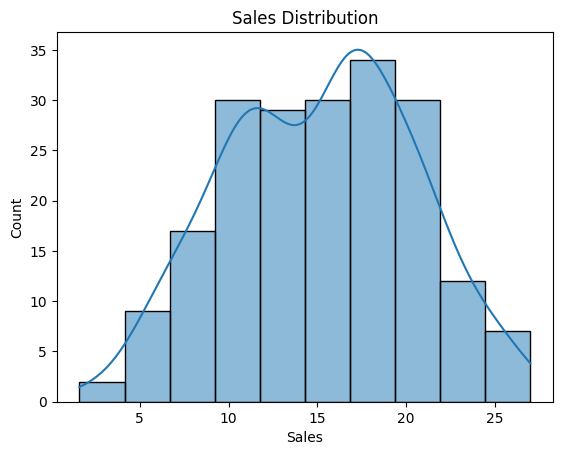

In [10]:
plt.figure()
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

In [11]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

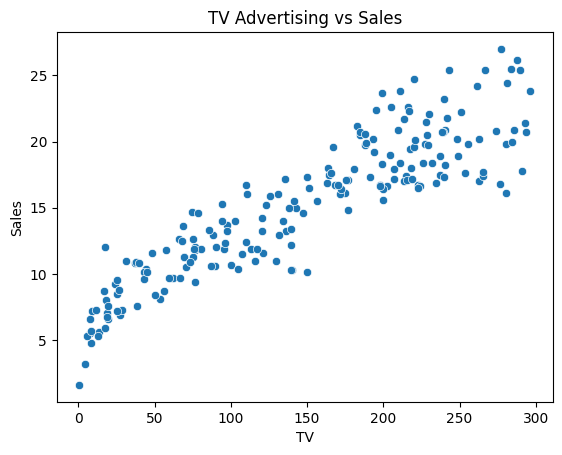

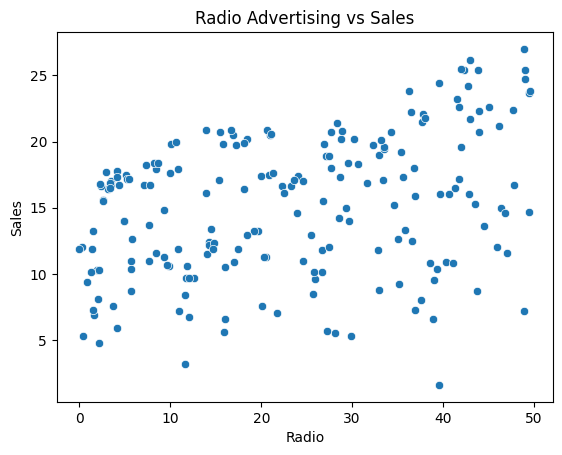

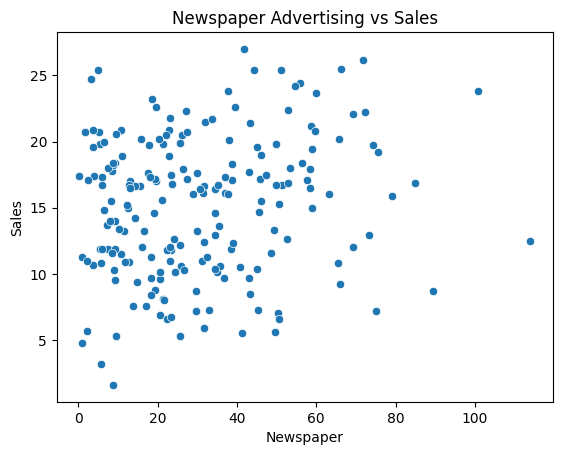

In [12]:
column=['TV', 'Radio', 'Newspaper']
for col in column:
    plt.figure()
    sns.scatterplot(x=col,y='Sales',data=df)
    plt.title(col+ " Advertising vs Sales")
    plt.show()

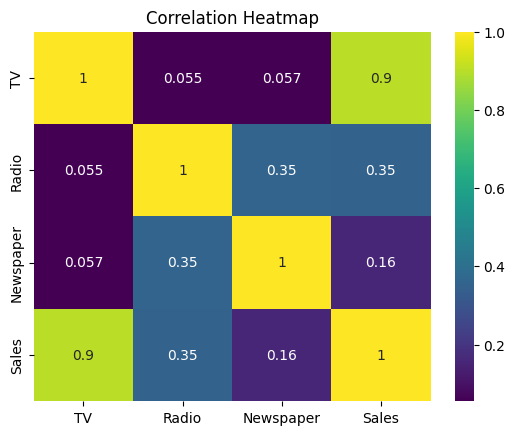

In [13]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

TV advertising has the strongest influence on sales, followed by Radio. Newspaper advertising shows minimal impact. Hence, TV and Radio are the most important features for sales prediction.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X=df[['TV','Radio','Newspaper']]
y=df['Sales']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
linearmodel=LinearRegression()

In [20]:
linearmodel.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linearmodel.coef_
})

coeff_df


,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


The Linear Regression coefficients show that Radio and TV advertisements significantly influence sales, while Newspaper advertisements have minimal effect. This indicates that businesses should focus more on TV and Radio advertising to maximize sales.

In [25]:
y_pred = linearmodel.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R2 Score: 0.9059011844150826


The Linear Regression model achieved an R² score of 0.91, indicating that advertising expenditure explains over 90% of the variance in sales, making it a highly effective predictive model

In [27]:
X_tvradio = df[['TV', 'Radio']]
y = df['Sales']


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tvradio, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression

linear_tvradio= LinearRegression()
linear_tvradio.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
coeff_df_new = pd.DataFrame({
    'Feature': X_tvradio.columns,
    'Coefficient': linear_tvradio.coef_
})

coeff_df_new


,Feature,Coefficient
0,TV,0.054507
1,Radio,0.103258


In [32]:
y_pred_new = linear_tvradio.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_new)
mse = mean_squared_error(y_test, y_pred_new)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_new)

print("MAE:", mae)
print("MSE:",mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1.2670422434730484
MSE: 2.846616122131541
RMSE: 1.6871917858179433
R2 Score: 0.9078797802624651


The regression model without newspaper data in the dataset achieved an R² score of 0.9079, which can be interpreted as approximately 90.8% accuracy in predicting sales. 

In [43]:
from sklearn.ensemble import RandomForestRegressor

In [44]:
X=df[['TV','Newspaper','Radio']]
y=df['Sales']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

In [47]:
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred_rf=rf_model.predict(X_test)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)


Random Forest MAE: 0.9197999999999993
Random Forest MSE: 1.4454012000000003
Random Forest RMSE: 1.2022483936358577
Random Forest R2 Score: 0.9532249272679614


In [52]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance.sort_values(by='Importance', ascending=False)


,Feature,Importance
0,TV,0.845511
2,Radio,0.136611
1,Newspaper,0.017878


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
X_tvradio=df[['TV','Radio']]
y=df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X_tvradio, y, test_size=0.2, random_state=42)

In [69]:
rf_model_tvradio=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model_tvradio.fit(X_train,y_train)



,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred_rf_tvradio=rf_model_tvradio.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf_tvradio)
mse_rf = mean_squared_error(y_test, y_pred_rf_tvradio)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf_tvradio)

print("Random Forest MAE:", mae_rf)
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)


Random Forest MAE: 0.8303249999999972
Random Forest MSE: 1.2428781749999982
Random Forest RMSE: 1.1148444622457423
Random Forest R2 Score: 0.9597788371611368


Newspaper was dropped because it had very low correlation with Sales (0.057) and a negligible regression coefficient (0.0043). After removing it, the Random Forest model showed improved performance: MAE decreased from 0.92 to 0.83, RMSE decreased from 1.20 to 1.11, and R² increased from 0.953 to 0.960

In [72]:
import pickle

with open('finalmodel.pkl', 'wb') as file:
    pickle.dump(rf_model_tvradio, file)


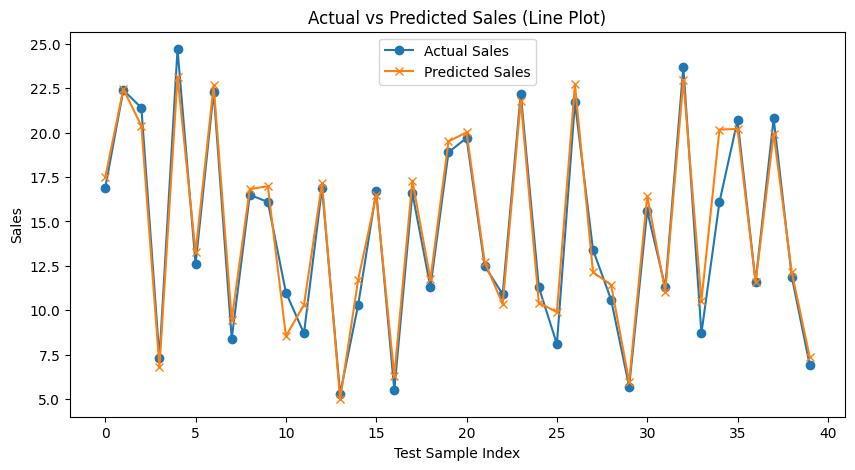

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

test_data = X_test.copy()
test_data['Sales_actual'] = y_test
test_data['Sales_predicted'] = rf_model_tvradio.predict(X_test)
test_data['Residuals'] = test_data['Sales_actual'] - test_data['Sales_predicted']

plt.figure(figsize=(10,5))
plt.plot(test_data['Sales_actual'].values, label='Actual Sales', marker='o')
plt.plot(test_data['Sales_predicted'].values, label='Predicted Sales', marker='x')
plt.xlabel("Test Sample Index")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales (Line Plot)")
plt.legend()
plt.show()